In [1]:
import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('../Excercises/08-Linear-Regression-Models/Advertising.csv')

In [3]:
df.head()

,TV,radio,newspaper,sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


In [4]:
df['total_spend'] = df['TV'] + df['radio'] + df['newspaper'] + df['sales']

In [5]:
df.head()

,TV,radio,newspaper,sales,total_spend
0,230.1,37.8,69.2,22.1,359.2
1,44.5,39.3,45.1,10.4,139.3
2,17.2,45.9,69.3,9.3,141.7
3,151.5,41.3,58.5,18.5,269.8
4,180.8,10.8,58.4,12.9,262.9


<Axes: xlabel='total_spend', ylabel='sales'>

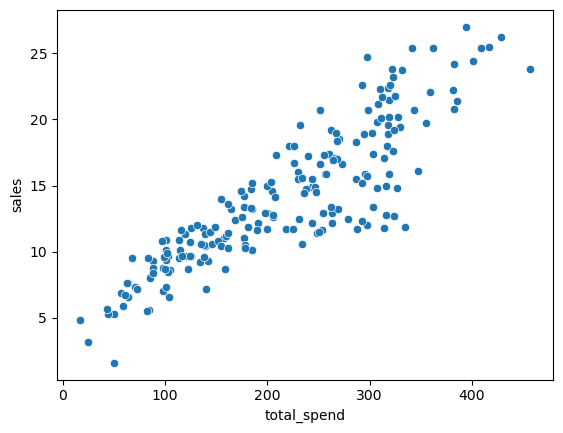

In [6]:
sns.scatterplot(data=df,x='total_spend',y='sales')

<Axes: xlabel='total_spend', ylabel='sales'>

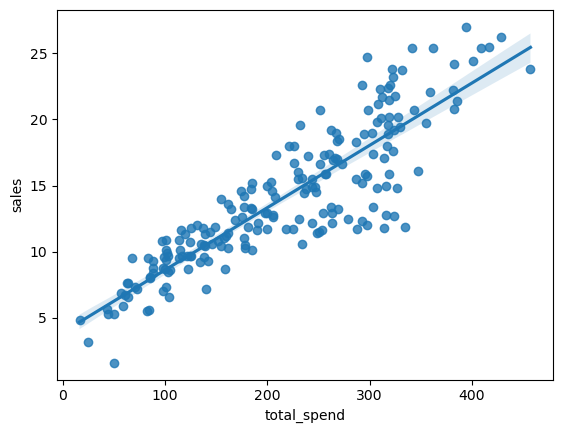

In [9]:
sns.regplot(data=df,x='total_spend',y='sales')

In [10]:
x = df['total_spend']
y = df['sales']

In [11]:
slope,intercept = np.polyfit(x,y,deg=1)

In [12]:
potential_spend = np.linspace(0,500,100)

In [13]:
predicted_sales = intercept + potential_spend*slope

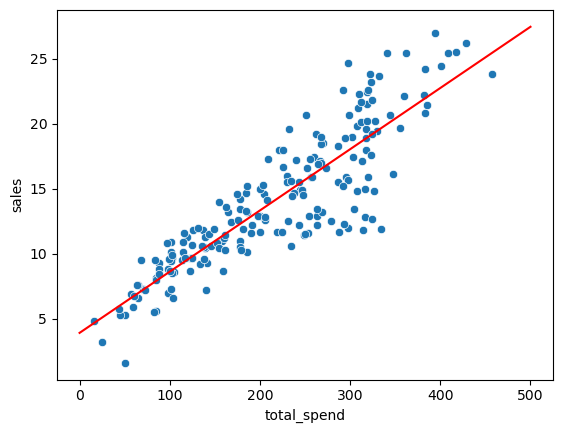

In [15]:
sns.scatterplot(data=df,x='total_spend',y='sales')
plt.plot(potential_spend,predicted_sales,color='red')

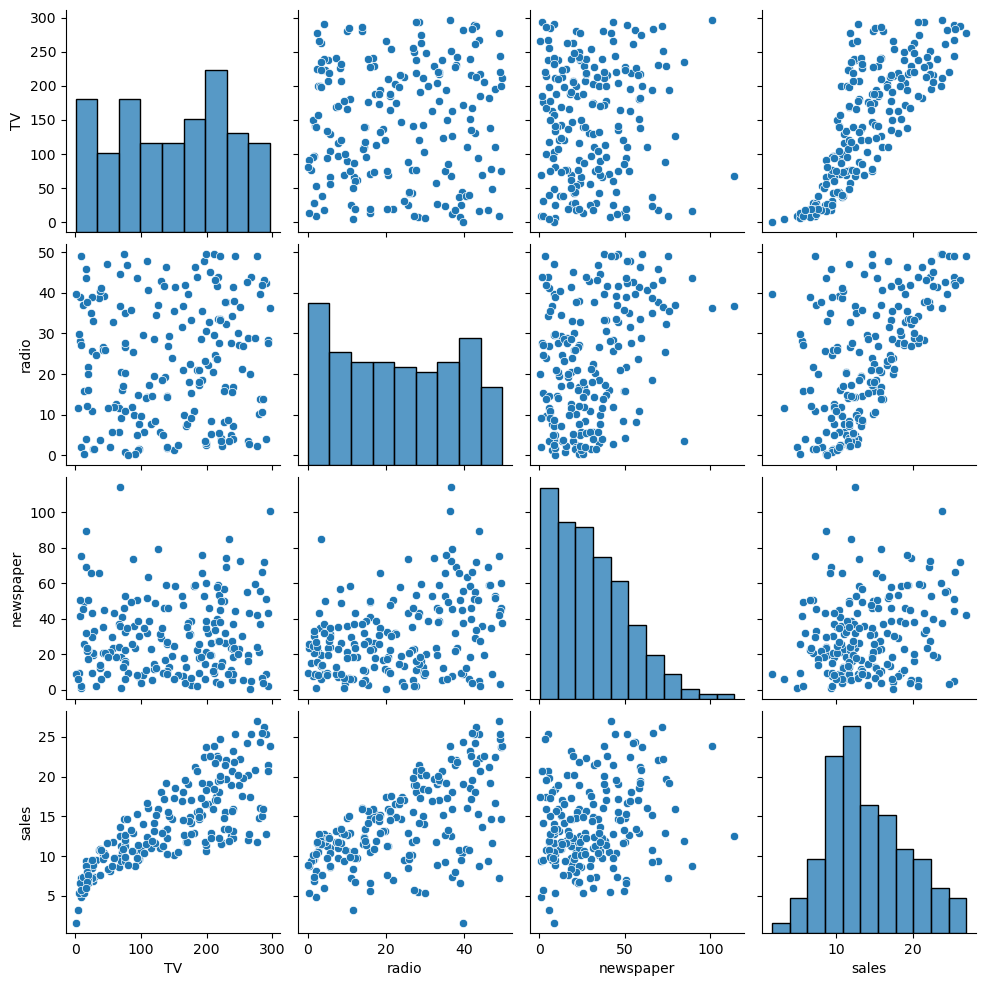

In [25]:
sns.pairplot(data=df[['TV', 'radio', 'newspaper', 'sales']])

<Axes: >

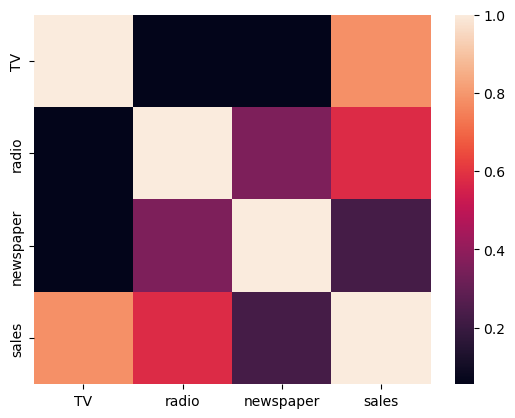

In [29]:
mat = df[['TV', 'radio', 'newspaper', 'sales']].corr()
sns.heatmap(mat)

In [34]:
x = df.drop(['total_spend','sales'],axis=1)
y = df['sales']

In [38]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=47)

In [39]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [40]:
predictions = model.predict(X_test)

In [42]:
predictions

array([12.60351987,  4.55710807, 20.57176395,  9.83200618,  3.64702102,
        8.45848621, 10.51235339, 23.40326202,  7.44595034, 18.46051944,
       15.51129985, 18.13501059, 16.78691074,  6.19171537, 12.9495217 ,
        8.51155269, 15.59272767, 19.29884955, 14.4997914 , 12.55303944,
       12.42606008, 15.5752302 , 10.03276132, 14.40032458, 20.87282613,
        7.67707634, 13.36377974, 15.19071152, 21.13630724,  7.07865399,
       18.26934105, 10.23681018,  8.88324587, 17.66422437,  8.85293974,
       11.39547576, 13.00109394, 14.64965107,  5.3637527 , 19.19830678])

In [51]:
y_train.mean(),y_train.median()

(np.float64(14.295000000000002), 13.25)

In [47]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,predictions)
print(mae)

1.3836057179961647


In [48]:
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test,predictions)
print(mse)

3.2099110389833667


In [49]:
from sklearn.metrics import root_mean_squared_error

rmse = root_mean_squared_error(y_test,predictions)
print(rmse)

1.7916224599461146


In [54]:
# Percentage of error interms of mean will be 12% more than average so on an average it will be off by 12%
(1.7/14)*100

12.142857142857142

In [55]:
residuals = y_test - predictions

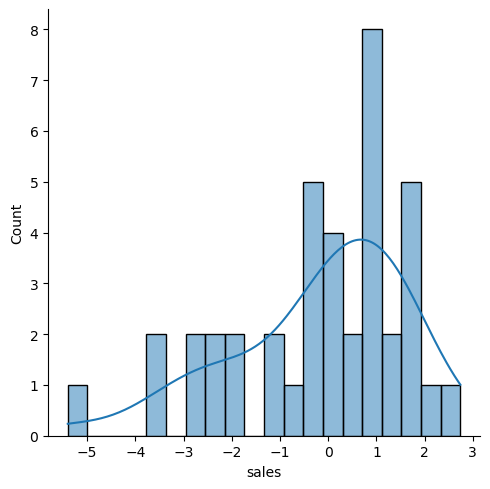

In [60]:
sns.displot(residuals,bins=20,kde=True)

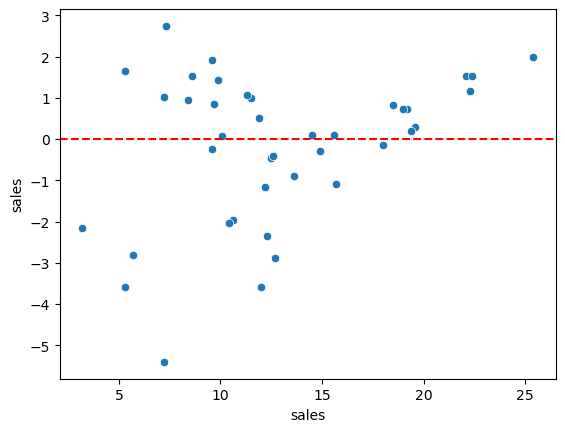

In [69]:
sns.scatterplot(x=y_test,y=residuals)
plt.axhline(y=0,color='red',ls='--')

In [70]:
# Polynomial regression

In [75]:
X = df.drop(columns = ['sales','total_spend'])
Y = df['sales']

In [76]:
X,Y

(        TV  radio  newspaper
 0    230.1   37.8       69.2
 1     44.5   39.3       45.1
 2     17.2   45.9       69.3
 3    151.5   41.3       58.5
 4    180.8   10.8       58.4
 ..     ...    ...        ...
 195   38.2    3.7       13.8
 196   94.2    4.9        8.1
 197  177.0    9.3        6.4
 198  283.6   42.0       66.2
 199  232.1    8.6        8.7
 
 [200 rows x 3 columns],
 0      22.1
 1      10.4
 2       9.3
 3      18.5
 4      12.9
        ... 
 195     7.6
 196     9.7
 197    12.8
 198    25.5
 199    13.4
 Name: sales, Length: 200, dtype: float64)

In [77]:
from sklearn.preprocessing import PolynomialFeatures

In [81]:
polynomial_convertor = PolynomialFeatures(degree=2,include_bias = False)

In [83]:
polynomial_convertor.fit(X)

,"degree degree: int or tuple (min_degree, max_degree), default=2If a single int is given, it specifies the maximal degree of thepolynomial features. If a tuple `(min_degree, max_degree)` is passed,then `min_degree` is the minimum and `max_degree` is the maximumpolynomial degree of the generated features. Note that `min_degree=0`and `min_degree=1` are equivalent as outputting the degree zero term isdetermined by `include_bias`.",2
,"interaction_only interaction_only: bool, default=FalseIf `True`, only interaction features are produced: features that areproducts of at most `degree` *distinct* input features, i.e. terms withpower of 2 or higher of the same input feature are excluded:- included: `x[0]`, `x[1]`, `x[0] * x[1]`, etc.- excluded: `x[0] ** 2`, `x[0] ** 2 * x[1]`, etc.",False
,"include_bias include_bias: bool, default=TrueIf `True` (default), then include a bias column, the feature in whichall polynomial powers are zero (i.e. a column of ones - acts as anintercept term in a linear model).",False
,"order order: {'C', 'F'}, default='C'Order of output array in the dense case. `'F'` order is faster tocompute, but may slow down subsequent estimators... versionadded:: 0.21",'C'


In [87]:
poly_features = polynomial_convertor.transform(X)

In [88]:
X

,TV,radio,newspaper
0,230.1,37.8,69.2
1,44.5,39.3,45.1
2,17.2,45.9,69.3
3,151.5,41.3,58.5
4,180.8,10.8,58.4
...,...,...,...
195,38.2,3.7,13.8
196,94.2,4.9,8.1
197,177.0,9.3,6.4
198,283.6,42.0,66.2


In [90]:
X.iloc[0]

TV           230.1
radio         37.8
newspaper     69.2
Name: 0, dtype: float64

In [92]:
poly_features[0]

array([2.301000e+02, 3.780000e+01, 6.920000e+01, 5.294601e+04,
       8.697780e+03, 1.592292e+04, 1.428840e+03, 2.615760e+03,
       4.788640e+03])

In [93]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(poly_features,Y,test_size=0.2,random_state=47)

In [94]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [95]:
predictions = model.predict(X_test)

In [96]:
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test,predictions)
print('mae ',mae)
mse = mean_squared_error(y_test,predictions)
print('mse ',mse)
rmse = root_mean_squared_error(y_test,predictions)
print('rmse ',rmse)

mae  0.5010428495859669
mse  0.4801785127158043
rmse  0.6929491415073723


In [99]:
print((0.6929491415073723/14)*100)

4.94963672505266


In [111]:
def metrics(actual,predictions):
    mae = mean_absolute_error(actual,predictions)
    print('mae ',mae)
    mse = mean_squared_error(actual,predictions)
    print('mse ',mse)
    rmse = root_mean_squared_error(actual,predictions)
    print('rmse ',rmse)
    return mae,mse,rmse

In [120]:
metrics_dict = {
    'degree': [],
    'mae_train': [],
    'mse_train': [],
    'rmse_train': [],
    'mae_test': [],
    'mse_test': [],
    'rmse_test': [],
}
for d in range(1,10):
    print(f'Degree - {d}')
    polynomial_convertor = PolynomialFeatures(degree=d,include_bias = False)
    polynomial_convertor.fit(X)
    poly_features = polynomial_convertor.transform(X)
    X_train,X_test,y_train,y_test = train_test_split(poly_features,Y,test_size=0.2,random_state=47)
    model = LinearRegression()
    model.fit(X_train,y_train)
    print('Train Metrics')
    mae,mse,rmse = metrics(y_train,model.predict(X_train))
    metrics_dict['degree'].append(d)
    metrics_dict['mae_train'].append(mae)
    metrics_dict['mse_train'].append(mse)
    metrics_dict['rmse_train'].append(rmse)
    
    predictions = model.predict(X_test)
    print('Test Metrics')
    mae,mse,rmse = metrics(y_test,predictions)
    metrics_dict['mae_test'].append(mae)
    metrics_dict['mse_test'].append(mse)
    metrics_dict['rmse_test'].append(rmse)

Degree - 1
Train Metrics
mae  1.209680202437108
mse  2.68067240751114
rmse  1.6372759106244554
Test Metrics
mae  1.3836057179961647
mse  3.2099110389833667
rmse  1.7916224599461146
Degree - 2
Train Metrics
mae  0.3926007631994942
mse  0.3494990921076376
rmse  0.5911844822960406
Test Metrics
mae  0.5010428495859669
mse  0.4801785127158043
rmse  0.6929491415073723
Degree - 3
Train Metrics
mae  0.30689136558058133
mse  0.21529653090913453
rmse  0.4640005721000078
Test Metrics
mae  0.3600906249303405
mse  0.26370344601941753
rmse  0.5135206383578147
Degree - 4
Train Metrics
mae  0.2696156262772422
mse  0.13501349222898668
rmse  0.3674418215568101
Test Metrics
mae  0.4392014839025384
mse  0.4037599245546568
rmse  0.635421060836558
Degree - 5
Train Metrics
mae  0.18120463897956257
mse  0.0587931709082421
rmse  0.2424730313008894
Test Metrics
mae  0.8106394845301192
mse  7.853590251833144
rmse  2.8024257798973276
Degree - 6
Train Metrics
mae  0.16793769987034768
mse  0.04816077860966958
rmse 

In [121]:
df_metrics = pd.DataFrame(data=metrics_dict)

In [129]:
pd.set_option('display.float_format', '{:.6f}'.format)

In [130]:
for col in df_metrics.columns:
    if df_metrics[col].dtype == float:
        df_metrics[col] = df_metrics[col].round(2)

In [132]:
cols = list(df_metrics.columns)
cols.sort()
df_metrics[cols]

,degree,mae_test,mae_train,mse_test,mse_train,rmse_test,rmse_train
0,1,1.380000,1.210000,3.210000,2.680000,1.790000,1.640000
1,2,0.500000,0.390000,0.480000,0.350000,0.690000,0.590000
2,3,0.360000,0.310000,0.260000,0.220000,0.510000,0.460000
3,4,0.440000,0.270000,0.400000,0.140000,0.640000,0.370000
4,5,0.810000,0.180000,7.850000,0.060000,2.800000,0.240000
5,6,4.460000,0.170000,603.210000,0.050000,24.560000,0.220000
6,7,2.260000,0.160000,79.840000,0.050000,8.940000,0.230000
7,8,47.930000,0.170000,78428.080000,0.090000,280.050000,0.310000
8,9,2312.470000,0.270000,212179538.190000,0.260000,14566.380000,0.510000


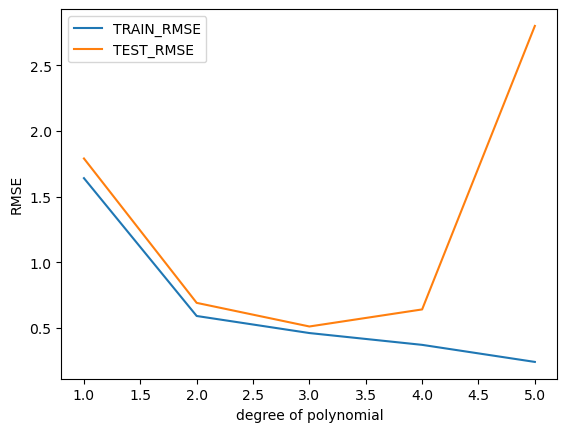

In [137]:
plt.plot(range(1,6),df_metrics['rmse_train'][:5],label='TRAIN_RMSE')
plt.plot(range(1,6),df_metrics['rmse_test'][:5],label='TEST_RMSE')
plt.xlabel('degree of polynomial')
plt.ylabel('RMSE')
plt.legend()